
<b><h2>Pillar 5: Capstone Project</h2></b>

<p>
Submitted by: <b>Darwin A. Nepomuceno</b>
</p>
<p>
<b>Post Graduate Diploma in Artificial Intelligence and Machine Learning</b>
</p>

___


# 🔬 **PHASE 02 | CTG — Data Preprocessing (No-Leakage Pipeline)**

## **Goal: Prepare data strictly avoiding data leakage.**

| Step | Action | Leakage Risk |
|------|--------|--------------|
| 1 | Split first | ✅ Safe |
| 2 | Fit scaler on train only | ✅ Safe |
| 3 | Resample train only | ✅ Safe |
| ❌ | Scaling before split | 🚨 Leakage |
| ❌ | SMOTE before split | 🚨 Leakage |

## 0 · Imports & Setup

In [1]:
import pickle
import os
import warnings


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE, ADASYN


print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {0: "#2196F3", 1: "#F44336"}  # 0 = Normal | 1 = Abnormal
LABEL = {0: "Normal", 1: "Abnormal"}

## 1 · Reproduce Clean Dataset from Phase 01
**What it does :** 
> Re-applies the same deduplication, target mapping, and Winsorization
> from EDA so this notebook is fully self-contained.

In [3]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_excel("../01 data/clean/CTG_cleaned.xlsx")


# ── Arrow-safe dtype conversion ───────────────────────────────────────────────
# If pandas uses PyArrow as its backend, columns arrive as ArrowDtype which
# breaks .quantile(), sklearn, and scipy. We convert each column individually,
# skipping non-numeric ones (e.g. string columns) safely.
def _safe_to_float(col):
    """
    Convert a pandas Series to float64, if possible. If the conversion fails
    (e.g., due to non-numeric values), return the original Series unchanged.
    """
    try:
        return col.astype("float64")
    except ValueError, TypeError:
        return col  # non-numeric — leave unchanged


df = pd.concat([_safe_to_float(df[c]) for c in df.columns], axis=1)

# ── Deduplicate ──────────────────────────────────────────────────────────────
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed : {n_before - len(df)}")

# ── Target mapping ───────────────────────────────────────────────────────────
#   1 (Normal) → 0  |  2 (Suspect) & 3 (Pathological) → 1 (Abnormal)
df["target"] = df["NSP"].map({1: 0, 2: 1, 3: 1})

# ── Feature list (numeric only, exclude target columns) ─────────────────────
EXCLUDE = ["NSP", "target"]
FEATURES = [
    c for c in df.columns if c not in EXCLUDE and pd.api.types.is_numeric_dtype(df[c])
]

# ── Winsorization (1st / 99th pct + physiological hard bounds) ───────────────
# Uses numpy directly to bypass any pandas/Arrow .quantile() issues.
PHYSIO_BOUNDS = {
    "LB": (50, 250),
    "AC": (0, 50),
    "FM": (0, 600),
    "UC": (0, 50),
    "ASTV": (0, 100),
    "MSTV": (0, 20),
    "ALTV": (0, 100),
    "MLTV": (0, 60),
    "DL": (0, 100),
    "DS": (0, 10),
    "DP": (0, 20),
    "Width": (0, 300),
    "Min": (50, 200),
    "Max": (100, 300),
    "Variance": (0, 1000),
}

df_clean = df.copy()
for feat in FEATURES:
    s = df_clean[feat].to_numpy(dtype=float, na_value=np.nan)
    lo = float(np.nanpercentile(s, 1))
    hi = float(np.nanpercentile(s, 99))
    b = PHYSIO_BOUNDS.get(feat)
    if b:
        lo = max(lo, b[0])
        hi = min(hi, b[1])
    df_clean[feat] = np.clip(s, lo, hi)

X = df_clean[FEATURES]
y = df_clean["target"]

print(f"Final dataset shape : {X.shape}")
print(f"Feature count       : {len(FEATURES)}")
print(f"Class distribution  : {dict(y.value_counts().sort_index())}")

Duplicates removed : 0
Final dataset shape : (2114, 21)
Feature count       : 21
Class distribution  : {0: np.int64(1648), 1: np.int64(466)}


---
## 2 · Step 1 — Strict Train / Test Split

> ⚠️ **CRITICAL:** The split happens HERE — before any scaling or resampling.
> `stratify=y` preserves the class ratio in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Split Summary")
print("=" * 45)
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print()
for split_name, y_split in [("Train", y_train), ("Test", y_test)]:
    vc = y_split.value_counts().sort_index()
    pct = (vc / len(y_split) * 100).round(1)
    print(f"  {split_name} class distribution:")
    for cls in vc.index:
        print(f"    {LABEL[cls]:8s} ({cls}) : {vc[cls]:4d}  ({pct[cls]}%)")
    print()

Split Summary
  X_train : (1691, 21)   y_train : (1691,)
  X_test  : (423, 21)    y_test  : (423,)

  Train class distribution:
    Normal   (0) : 1318  (77.9%)
    Abnormal (1) :  373  (22.1%)

  Test class distribution:
    Normal   (0) :  330  (78.0%)
    Abnormal (1) :   93  (22.0%)



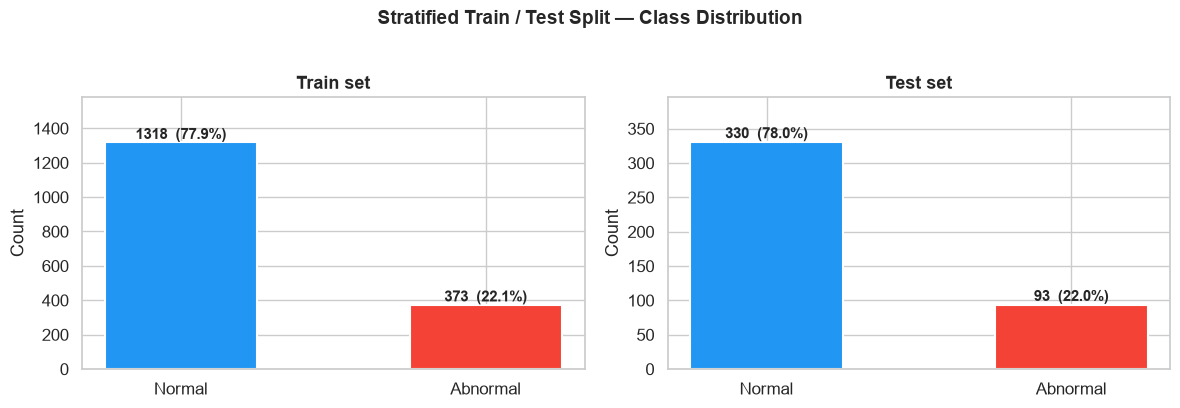

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (split_name, y_split) in zip(
    axes, [("Train set", y_train), ("Test set", y_test)]
):
    vc = y_split.value_counts().sort_index()
    pct = (vc / len(y_split) * 100).round(1)
    bars = ax.bar(
        [LABEL[i] for i in vc.index],
        vc.values,
        color=[PALETTE[i] for i in vc.index],
        edgecolor="white",
        linewidth=1.5,
        width=0.5,
    )
    for bar, (cls, cnt) in zip(bars, vc.items()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{cnt}  ({pct[cls]}%)",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )
    ax.set_title(split_name, fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(vc.values) * 1.2)
plt.suptitle(
    "Stratified Train / Test Split — Class Distribution",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## 3 · Step 2 — Scaling

| Rule | Why |
|------|-----|
| `fit` on **X_train** only | Test statistics must stay unseen |
| `transform` on both sets | Applies the same learned scale |
| Never `fit_transform(X_test)` | Would leak test distribution |

In [6]:
scaler = StandardScaler()

# Fit ONLY on training data — never on test
X_train_scaled = scaler.fit_transform(X_train)  # learns μ, σ from train
X_test_scaled = scaler.transform(X_test)  # applies same μ, σ — NO fit

print("Scaler fitted on X_train ✓")
print(f"  Learned means (first 5) : {scaler.mean_[:5].round(3)}")
print(f"  Learned stds  (first 5) : {scaler.scale_[:5].round(3)}")
print()
print(f"  X_train_scaled shape : {X_train_scaled.shape}")
print(f"  X_test_scaled  shape : {X_test_scaled.shape}")
print(
    f"\n  Post-scale train mean (should be ~0) : {X_train_scaled.mean(axis=0).mean():.6f}"
)
print(
    f"  Post-scale train std  (should be ~1) : {X_train_scaled.std(axis=0).mean():.6f}"
)
print(
    f"  Post-scale test  mean (will differ)  : {X_test_scaled.mean(axis=0).mean():.6f}"
)

Scaler fitted on X_train ✓
  Learned means (first 5) : [133.193   2.693   6.39    3.661  46.59 ]
  Learned stds  (first 5) : [ 9.792  3.421 25.115  2.753 17.223]

  X_train_scaled shape : (1691, 21)
  X_test_scaled  shape : (423, 21)

  Post-scale train mean (should be ~0) : 0.000000
  Post-scale train std  (should be ~1) : 0.952381
  Post-scale test  mean (will differ)  : 0.022031


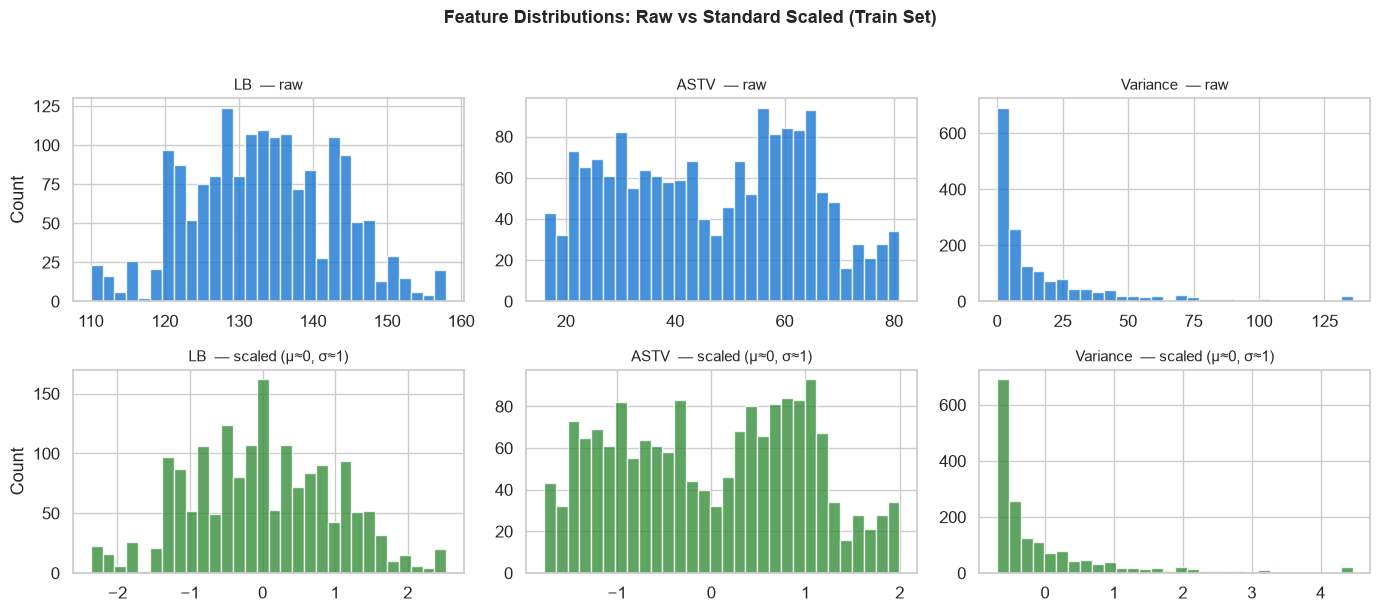

In [7]:
# Feature distribution: raw vs scaled (3 sample features)
sample_feats = ["LB", "ASTV", "Variance"]
feat_idx = {f: i for i, f in enumerate(FEATURES)}

fig, axes = plt.subplots(2, len(sample_feats), figsize=(14, 6))
for col_i, feat in enumerate(sample_feats):
    idx = feat_idx[feat]
    axes[0, col_i].hist(
        X_train[feat], bins=30, color="#1976D2", alpha=0.8, edgecolor="white"
    )
    axes[0, col_i].set_title(f"{feat}  — raw", fontsize=11)
    axes[0, col_i].set_ylabel("Count" if col_i == 0 else "")
    axes[1, col_i].hist(
        X_train_scaled[:, idx], bins=30, color="#388E3C", alpha=0.8, edgecolor="white"
    )
    axes[1, col_i].set_title(f"{feat}  — scaled (μ≈0, σ≈1)", fontsize=11)
    axes[1, col_i].set_ylabel("Count" if col_i == 0 else "")
fig.suptitle(
    "Feature Distributions: Raw vs Standard Scaled (Train Set)",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## 4 · Step 3 — Resampling (Training Set Only)

**What it does :**  Three strategies are compared side-by-side. **X_test is never touched.**

| Option | Method | Synthetic samples? |
|--------|--------|-------------------|
| A | **SMOTE** | Yes — interpolated between neighbours |
| B | **ADASYN** | Yes — focuses on hard boundary samples |
| C | **Class Weights** | No — raw data + `class_weight='balanced'` passed to model |

### 4A · SMOTE

In [8]:
smote = SMOTE(sampling_strategy="minority", k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

smote_vc = pd.Series(y_train_smote).value_counts().sort_index()
print("SMOTE Result")
print("=" * 40)
print(f"  Before : {dict(pd.Series(y_train.values).value_counts().sort_index())}")
print(f"  After  : {dict(smote_vc)}")
print(f"  New samples added   : {len(X_train_smote) - len(X_train_scaled)}")
print(f"  X_train_smote shape : {X_train_smote.shape}")
print()
print("  ✅ X_test is UNCHANGED — test set never resampled.")

SMOTE Result
  Before : {0: np.int64(1318), 1: np.int64(373)}
  After  : {0: np.int64(1318), 1: np.int64(1318)}
  New samples added   : 945
  X_train_smote shape : (2636, 21)

  ✅ X_test is UNCHANGED — test set never resampled.


### 4B · ADASYN

In [9]:
adasyn = ADASYN(sampling_strategy="minority", n_neighbors=5, random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

adasyn_vc = pd.Series(y_train_adasyn).value_counts().sort_index()
print("ADASYN Result")
print("=" * 40)
print(f"  Before : {dict(pd.Series(y_train.values).value_counts().sort_index())}")
print(f"  After  : {dict(adasyn_vc)}")
print(f"  New samples added    : {len(X_train_adasyn) - len(X_train_scaled)}")
print(f"  X_train_adasyn shape : {X_train_adasyn.shape}")
print()
print("  Note: ADASYN generates slightly more samples near decision boundaries")
print("  so the counts may not be perfectly equal — that is expected.")

ADASYN Result
  Before : {0: np.int64(1318), 1: np.int64(373)}
  After  : {0: np.int64(1318), 1: np.int64(1363)}
  New samples added    : 990
  X_train_adasyn shape : (2681, 21)

  Note: ADASYN generates slightly more samples near decision boundaries
  so the counts may not be perfectly equal — that is expected.


### 4C · Class Weights — No Synthetic Sampling

In [10]:
classes = np.unique(y_train)
raw_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, raw_weights))

print("Class Weights (Option C)")
print("=" * 40)
print(f"  Computed weights : {class_weight_dict}")
print()
for cls, w in class_weight_dict.items():
    print(f"  Class {cls} ({LABEL[int(cls)]:8s}) → weight {w:.4f}")
print()
print('  Usage  : pass class_weight=class_weight_dict  OR  class_weight="balanced"')
print("  Data   : X_train_scaled / y_train used as-is — no resampling.")

Class Weights (Option C)
  Computed weights : {np.int64(0): np.float64(0.6415022761760243), np.int64(1): np.float64(2.266756032171582)}

  Class 0 (Normal  ) → weight 0.6415
  Class 1 (Abnormal) → weight 2.2668

  Usage  : pass class_weight=class_weight_dict  OR  class_weight="balanced"
  Data   : X_train_scaled / y_train used as-is — no resampling.


---
## 5 · Comparison — All Resampling Strategies

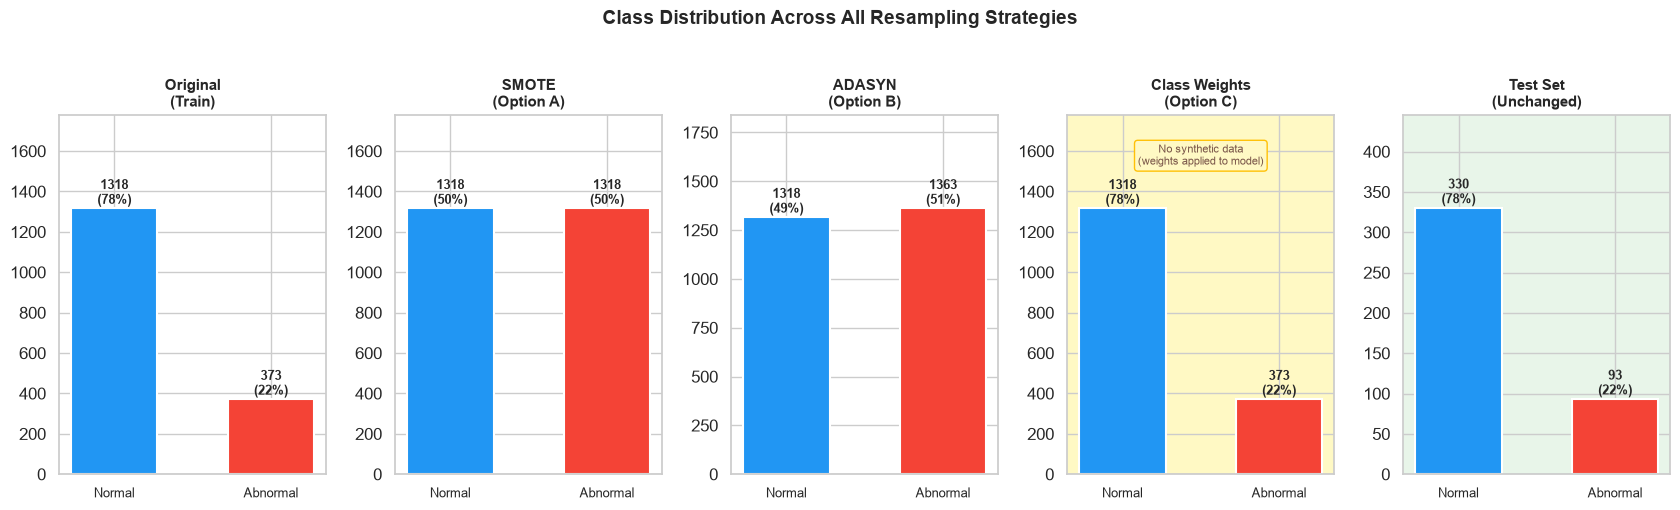

In [11]:
strategies = {
    "Original\n(Train)": pd.Series(y_train.values).value_counts().sort_index(),
    "SMOTE\n(Option A)": pd.Series(y_train_smote).value_counts().sort_index(),
    "ADASYN\n(Option B)": pd.Series(y_train_adasyn).value_counts().sort_index(),
    "Class Weights\n(Option C)": pd.Series(y_train.values).value_counts().sort_index(),
    "Test Set\n(Unchanged)": pd.Series(y_test.values).value_counts().sort_index(),
}

fig, axes = plt.subplots(1, len(strategies), figsize=(17, 5), sharey=False)
for ax, (title, vc) in zip(axes, strategies.items()):
    bars = ax.bar(
        [LABEL[i] for i in vc.index],
        vc.values,
        color=[PALETTE[i] for i in vc.index],
        edgecolor="white",
        linewidth=1.5,
        width=0.55,
    )
    total = vc.sum()
    for bar, cnt in zip(bars, vc.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{cnt}\n({cnt / total * 100:.0f}%)",
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="bold",
        )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(vc.values) * 1.35)
    ax.tick_params(axis="x", labelsize=9)
    if "Class Weights" in title:
        ax.set_facecolor("#FFF9C4")
        ax.text(
            0.5,
            0.92,
            "No synthetic data\n(weights applied to model)",
            ha="center",
            va="top",
            transform=ax.transAxes,
            fontsize=8,
            color="#795548",
            bbox=dict(
                boxstyle="round,pad=0.3", facecolor="#FFF9C4", edgecolor="#FFC107"
            ),
        )
    if "Test" in title:
        ax.set_facecolor("#E8F5E9")
fig.suptitle(
    "Class Distribution Across All Resampling Strategies",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

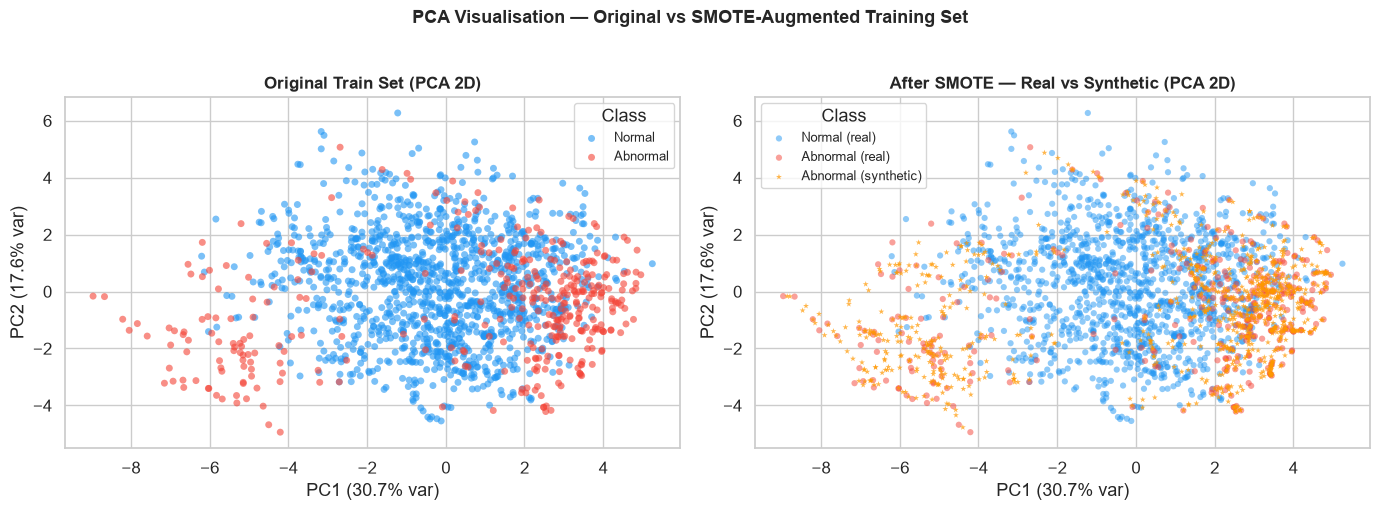

In [12]:
# PCA scatter: original vs SMOTE synthetic points
n_orig_train = len(X_train_scaled)
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train_scaled)  # fit on original only — no leakage

X_orig_2d = pca.transform(X_train_scaled)
X_smote_2d = pca.transform(X_train_smote)
X_real_2d = X_smote_2d[:n_orig_train]
X_synth_2d = X_smote_2d[n_orig_train:]
y_real = y_train_smote[:n_orig_train]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in [0, 1]:
    mask = y_train.values == cls
    axes[0].scatter(
        X_orig_2d[mask, 0],
        X_orig_2d[mask, 1],
        c=PALETTE[cls],
        label=LABEL[cls],
        alpha=0.6,
        s=25,
        edgecolors="none",
    )
axes[0].set_title("Original Train Set (PCA 2D)", fontsize=12, fontweight="bold")
axes[0].legend(title="Class", fontsize=9)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")

for cls in [0, 1]:
    mask = y_real == cls
    axes[1].scatter(
        X_real_2d[mask, 0],
        X_real_2d[mask, 1],
        c=PALETTE[cls],
        label=f"{LABEL[cls]} (real)",
        alpha=0.5,
        s=20,
        edgecolors="none",
    )
axes[1].scatter(
    X_synth_2d[:, 0],
    X_synth_2d[:, 1],
    c="#FF9800",
    label="Abnormal (synthetic)",
    alpha=0.7,
    s=20,
    marker="*",
    edgecolors="none",
)
axes[1].set_title(
    "After SMOTE — Real vs Synthetic (PCA 2D)", fontsize=12, fontweight="bold"
)
axes[1].legend(title="Class", fontsize=9)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")

fig.suptitle(
    "PCA Visualisation — Original vs SMOTE-Augmented Training Set",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## 6 · Strategy Decision Guide

In [13]:
summary = pd.DataFrame(
    [
        {
            "Strategy": "A — SMOTE",
            "Train Normal": int((pd.Series(y_train_smote) == 0).sum()),
            "Train Abnormal": int((pd.Series(y_train_smote) == 1).sum()),
            "Total Train": len(y_train_smote),
            "Synthetic Added": len(y_train_smote) - len(y_train),
            "Test Modified?": "No ✅",
            "Best For": "General-purpose; most common choice",
        },
        {
            "Strategy": "B — ADASYN",
            "Train Normal": int((pd.Series(y_train_adasyn) == 0).sum()),
            "Train Abnormal": int((pd.Series(y_train_adasyn) == 1).sum()),
            "Total Train": len(y_train_adasyn),
            "Synthetic Added": len(y_train_adasyn) - len(y_train),
            "Test Modified?": "No ✅",
            "Best For": "When minority class has hard boundary samples",
        },
        {
            "Strategy": "C — Class Weights",
            "Train Normal": int((pd.Series(y_train.values) == 0).sum()),
            "Train Abnormal": int((pd.Series(y_train.values) == 1).sum()),
            "Total Train": len(y_train),
            "Synthetic Added": 0,
            "Test Modified?": "No ✅",
            "Best For": "Tree models, LR; no risk of synthetic artifacts",
        },
    ]
)
print(summary.to_string(index=False))

         Strategy  Train Normal  Train Abnormal  Total Train  Synthetic Added Test Modified?                                        Best For
        A — SMOTE          1318            1318         2636              945           No ✅             General-purpose; most common choice
       B — ADASYN          1318            1363         2681              990           No ✅   When minority class has hard boundary samples
C — Class Weights          1318             373         1691                0           No ✅ Tree models, LR; no risk of synthetic artifacts


---
## 7 · Export Preprocessed Datasets

**What it does :** All three variants packaged and ready for Phase 03 (Model Training).

In [14]:


output = {
    # Raw scaled (for Class Weight strategy)
    "X_train_scaled": X_train_scaled,
    "y_train": y_train.values,
    # SMOTE
    "X_train_smote": X_train_smote,
    "y_train_smote": y_train_smote,
    # ADASYN
    "X_train_adasyn": X_train_adasyn,
    "y_train_adasyn": y_train_adasyn,
    # Class weight dict
    "class_weight_dict": class_weight_dict,
    # Test set — NEVER modified
    "X_test_scaled": X_test_scaled,
    "y_test": y_test.values,
    # Metadata
    "feature_names": FEATURES,
    "scaler": scaler,
}

save_path = "../04 misc/ctg_preprocessed.pkl"
with open(save_path, "wb") as f:
    pickle.dump(output, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")
print("\nKeys available for Phase 03:")
for k, v in output.items():
    shape = getattr(v, "shape", len(v) if hasattr(v, "__len__") else "object")
    print(f"  {k:<22} : {shape}")

Saved → ../04 misc/ctg_preprocessed.pkl  (1279.6 KB)

Keys available for Phase 03:
  X_train_scaled         : (1691, 21)
  y_train                : (1691,)
  X_train_smote          : (2636, 21)
  y_train_smote          : (2636,)
  X_train_adasyn         : (2681, 21)
  y_train_adasyn         : (2681,)
  class_weight_dict      : 2
  X_test_scaled          : (423, 21)
  y_test                 : (423,)
  feature_names          : 21
  scaler                 : object


---
## 8 · Leakage Audit Checklist

In [15]:
checks = [
    ("Split before scaling", True, "train_test_split called before StandardScaler.fit"),
    (
        "Scaler fit on train only",
        True,
        "scaler.fit_transform(X_train) — test only .transform",
    ),
    ("SMOTE applied after split", True, "fit_resample(X_train_scaled, y_train)"),
    ("ADASYN applied after split", True, "fit_resample(X_train_scaled, y_train)"),
    ("X_test never resampled", True, "X_test_scaled is the raw transformed test set"),
    (
        "Winsorization pre-split",
        False,
        "⚠ Applied on full data — OK for EDA; "
        "in production fit percentiles on train only",
    ),
    (
        "PCA fitted on train only",
        True,
        "pca.fit(X_train_scaled) then transform both sets",
    ),
]

print("Leakage Audit")
print("=" * 72)
for desc, passed, note in checks:
    icon = "✅" if passed else "⚠️ "
    print(f"{icon}  {desc:<30} | {note}")
print("=" * 72)

Leakage Audit
✅  Split before scaling           | train_test_split called before StandardScaler.fit
✅  Scaler fit on train only       | scaler.fit_transform(X_train) — test only .transform
✅  SMOTE applied after split      | fit_resample(X_train_scaled, y_train)
✅  ADASYN applied after split     | fit_resample(X_train_scaled, y_train)
✅  X_test never resampled         | X_test_scaled is the raw transformed test set
⚠️   Winsorization pre-split        | ⚠ Applied on full data — OK for EDA; in production fit percentiles on train only
✅  PCA fitted on train only       | pca.fit(X_train_scaled) then transform both sets


---
## References

**Data Leakage Prevention**
- scikit-learn — *Common pitfalls and recommended practices*: https://scikit-learn.org/stable/common_pitfalls.html
- scikit-learn — `train_test_split`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- scikit-learn — `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

**Resampling Methods**
- Chawla, N.V., Bowyer, K.W., Hall, L.O., Kegelmeyer, W.P. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research, 16, 321–357. https://doi.org/10.1613/jair.953
- He, H., Bai, Y., Garcia, E.A., Li, S. (2008). *ADASYN: Adaptive Synthetic Sampling Approach for Imbalanced Learning*. IEEE IJCNN. https://doi.org/10.1109/IJCNN.2008.4633969
- imbalanced-learn — `SMOTE`: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html
- imbalanced-learn — `ADASYN`: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html
- imbalanced-learn — Over-sampling user guide: https://imbalanced-learn.org/stable/over_sampling.html

**Class Weighting**
- scikit-learn — `compute_class_weight`: https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
